# Проект: Анализ маркетинговых вложений на продвижение развлекательного приложения

**Описание и задачи проекта:**

Несмотря на огромные вложения в рекламу, известое развлекательное приложение  последние несколько месяцев компания терпит убытки. 

Задача исследования: разобраться в причинах и помочь компании выйти в плюс.

В том числе, изучить:
 - откуда приходят пользователи и какими устройствами они пользуются
 - сколько стоит привлечение пользователей из различных рекламных каналов
 - сколько денег приносит каждый клиент
 - когда расходы на привлечение клиента окупаются
 - какие факторы мешают привлечению клиентов

**Описание данных:**

Данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года.


Файл с информацией о посещениях сайта, visits_info_short.csv:
 - User Id — уникальный идентификатор пользователя
 - Region — страна пользователя
 - Device — тип устройства пользователя
 - Channel — идентификатор источника перехода
 - Session Start — дата и время начала сессии
 - Session End — дата и время окончания сессии

Файл с информацией о заказах, orders_info_short.csv:
 - User Id — уникальный идентификатор пользователя
 - Event Dt — дата и время покупки
 - Revenue — сумма заказа

Файл с информацией о расходах на рекламу, costs_info_short.csv:
 - dt — дата проведения рекламной кампании
 - Channel — идентификатор рекламного источника
 - costs — расходы на эту кампанию

**Содержание работа:**

**1.Загрузка данных и подготовка к анализу**

1.1 Предобработка датафрейм с данными о посещениях приложения

1.2 Предобработка датафрейм с данными о покупках в приложении

1.3 Предобработка датафрейм с данными о затратах на маркетинг

**2.Формирование функций для расчёта и анализа LTV, ROI, удержания и конверсии.**

   *Функции для вычисления значений метрик:*

2.1 Функция для создания профилей пользователей

2.2 Функция для подсчёта Retention Rate

2.3 Функция для подсчёта конверсии

2.4 Функция для подсчёта LTV и ROI

   *Функции для построения графиков:*

2.5 Функция для сглаживания данных

2.6 Функция для построения графика Retention Rate

2.7 Функция для построения графика конверсии

2.8 Функция для визуализации LTV и ROI

**3.Исследовательский анализ данных**

3.1 Профили пользователей

3.2 Страны, из которых пользователи приходят в приложение

3.3 Устройства, которыми пользуются пользователи

3.4 Рекламные источники привлечения

**4.Маркетинг**

4.1 Общая сумма расходов на маркетинг

4.2 Распределение затрат по источникам

4.3 Динамика затрат по неделям и месяцам

4.4 Расчет САС по каждому источнику

**5.Оценка окупаемости рекламы**

5.1 Оценка окупаемости с помощью LTV, CAC, ROI

5.2 Конверсия и удержание пользователей

5.3 Анализ окупаемости с разбивкой по устройствам

5.4 Анализ окупаемости с разбивкой по странам

5.5 Анализ окупаемости с разбивкой по рекламным каналам

**6.Выводы и рекомендации**

## Загрузка данных и подготовка к анализу

In [1]:
# импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib import pyplot as plt

In [2]:
# Чтение файлов и сохранение в датафреймы
visits, orders, costs = (
    pd.read_csv('****'),  # журнал визитов
    pd.read_csv('****'),  # заказы
    pd.read_csv('****'),  # расходы
)

visits.to_csv('visits_info_short.csv', index=False)  
orders.to_csv('orders_info_short.csv', index=False) 
costs.to_csv('costs_info_short.csv', index=False) 

**Выполним предобработку каждого датафрейма, изучим на предмет пропусков, дубликатов, типов данных.**

### Предобработка датафрейм с данными о посещениях приложения

In [3]:
# Основная информация о датафрейме с посещениями приложения
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


**Пропусков нет.**

**Необходимо привести названия столбцов к верному стилю.**

**Столбцы session_start и session_end необходимо привести к верному типу данных datetime.**


In [4]:
# Изменяем названия столбцов
visits.columns = ['user_id','region','device', 'channel','session_start','session_end']

# Преобразуем текстовые столбцы session_start и session_end в даты
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])


In [5]:
# Проверяем верность преобразований
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


In [6]:
visits.head()

,user_id,region,device,channel,session_start,session_end
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


In [7]:
# Проверяем наличие явных дубликатов
visits.duplicated().sum()

0

In [8]:
# Проверяем наличие неявных дубликатов
print(visits['region'].unique().tolist())
print(visits['device'].unique().tolist())
print(visits['channel'].unique().tolist())

['United States', 'UK', 'France', 'Germany']
['iPhone', 'Mac', 'Android', 'PC']
['organic', 'TipTop', 'RocketSuperAds', 'YRabbit', 'FaceBoom', 'MediaTornado', 'AdNonSense', 'LeapBob', 'WahooNetBanner', 'OppleCreativeMedia', 'lambdaMediaAds']


**Дубликатов явных и неявных не выявлено.**

### Предобработка датафрейм с данными о покупках в приложении

In [9]:
# Основная информация о датафрейме с покупками в приложении
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


**Пропусков нет.**

**Необходимо привести названия столбцов к верному стилю.**

**Столбец Event Dt необходимо привести к верному типу данных datetime.**


In [10]:
# Изменяем название столбца
orders.columns = ['user_id', 'event_dt','revenue']

# Преобразуем текстовый столбец в дату
orders['event_dt'] = pd.to_datetime(orders['event_dt'])

In [11]:
# Проверяем верность преобразований
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


In [12]:
orders.head()

,user_id,event_dt,revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


In [13]:
# Проверяем наличие явных дубликатов
orders.duplicated().sum()

0

### Предобработка датафрейм с данными о затратах на маркетинг

In [14]:
# Основная информация о датафрейме с затратами на маркетинг
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


**Пропусков нет.**

**Необходимо привести названия столбцов к верному стилю.**

**Столбец dt необходимо привести к верному типу данных datetime.**

In [15]:
# Переименование столбцов
costs.columns=['dt', 'channel','costs']

# Преобразуем текстовый столбец в дату
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

In [16]:
# Проверяем верность преобразований
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


In [17]:
costs.head()

,dt,channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


In [18]:
# Проверяем наличие явных дубликатов
costs.duplicated().sum()

0

In [19]:
# Проверяем наличие неявных дубликатов
costs['channel'].unique().tolist()

['FaceBoom',
 'MediaTornado',
 'RocketSuperAds',
 'TipTop',
 'YRabbit',
 'AdNonSense',
 'LeapBob',
 'OppleCreativeMedia',
 'WahooNetBanner',
 'lambdaMediaAds']

**Дубликаты не выявлены.**

## Формирование функций для расчёта и анализа LTV, ROI, удержания и конверсии.


Функции для вычисления значений метрик:

- `get_profiles()` — для создания профилей пользователей,
- `get_retention()` — для подсчёта Retention Rate,
- `get_conversion()` — для подсчёта конверсии,
- `get_ltv()` — для подсчёта LTV и ROI.

Функции для построения графиков:

- `filter_data()` — для сглаживания данных,
- `plot_retention()` — для построения графика Retention Rate,
- `plot_conversion()` — для построения графика конверсии,
- `plot_ltv_roi` — для визуализации LTV и ROI.

### Функция для создания профилей пользователей.

In [20]:
# Создаем функцию для создания пользовательских профилей

def get_profiles(sessions, orders, ad_costs):

    # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].values.astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())


    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

### Функция для подсчёта Retention Rate

In [21]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

### Функция для подсчёта конверсии

In [22]:
# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

### Функция для подсчёта LTV и ROI

In [23]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    ) 

### Функция для сглаживания данных

In [24]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

### Функция для построения графика Retention Rate

In [25]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=14):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show() 

### Функция для построения графика конверсии

In [26]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=14):

    # задаём размер сетки для графиков
    plt.figure(figsize=(20, 10))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

### Функция для визуализации LTV и ROI

In [27]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=14):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

## Исследовательский анализ данных

#### Профили пользователей

In [28]:
# Составляем профили пользователей
profiles = get_profiles(visits, orders, costs)
profiles.head(10)

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769
5,34186288,2019-05-09 17:29:23,organic,Android,United States,2019-05-09,2019-05-01,False,0.000000
6,38448301,2019-08-16 11:56:00,organic,Android,United States,2019-08-16,2019-08-01,False,0.000000
7,46006712,2019-06-30 03:46:29,AdNonSense,Android,France,2019-06-30,2019-06-01,True,1.008000
8,58263264,2019-05-11 19:18:43,FaceBoom,iPhone,United States,2019-05-11,2019-05-01,False,1.128205
9,59835779,2019-05-11 21:13:47,MediaTornado,iPhone,United States,2019-05-11,2019-05-01,False,0.250435


In [29]:
# Определяем минимальную и максимальную даты привлечения пользователей.
first_ts_min = profiles['first_ts'].min().date()
first_ts_max = profiles['first_ts'].max().date()
print('Минимальная дата привлечения :',  first_ts_min)
print('Максимальная дата привлечения :', first_ts_max)

Минимальная дата привлечения : 2019-05-01
Максимальная дата привлечения : 2019-10-27


**Минимальная и максимальная даты совпадают с исходными условиями, можно сделать вывод, что профили пользовтелей составлены верно.**

#### Страны, из которых пользователи приходят в приложение.

In [30]:
# Формируем таблицу с общим кол-вом пользователей, а также кол-вом и долей платящих пользователей
country_payer = profiles.groupby(by='region').agg({'user_id':'count','payer':'sum'}).reset_index()
country_payer['payer_part'] = round((country_payer['payer']/country_payer['user_id'])*100,2)
country_payer = country_payer.sort_values(by='user_id', ascending=False) 
country_payer

,region,user_id,payer,payer_part
3,United States,100002,6902,6.90
2,UK,17575,700,3.98
0,France,17450,663,3.80
1,Germany,14981,616,4.11


**Построим графики для наглядности.**

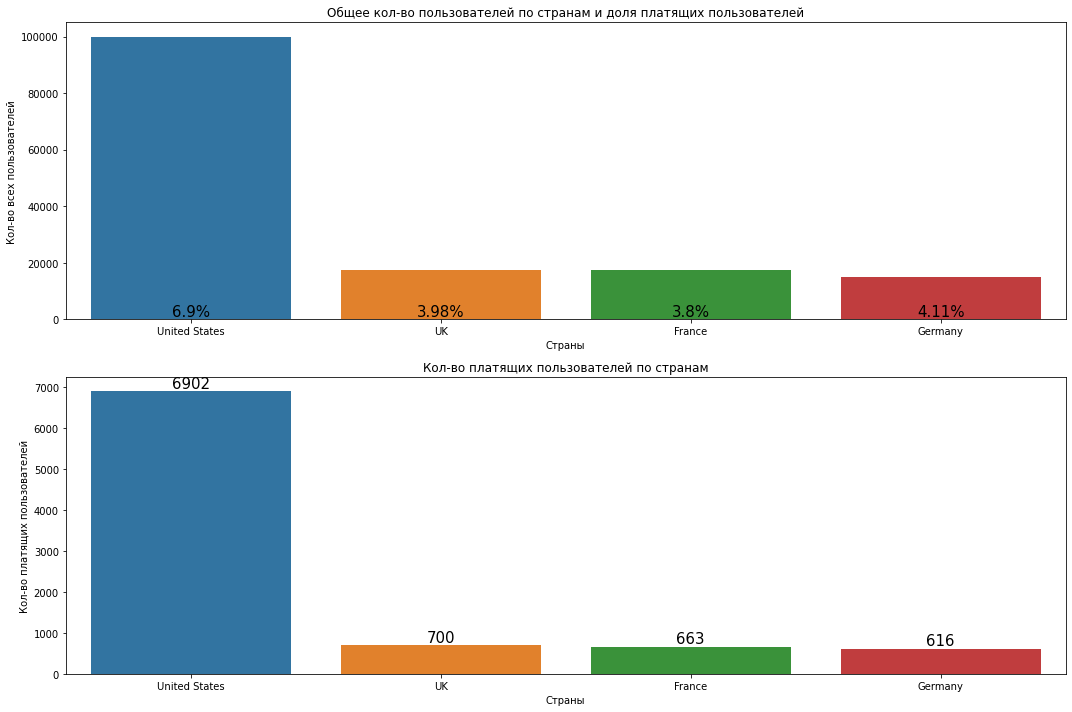

In [31]:
# Задаем размер сетки
plt.figure(figsize=(15, 10))
# Задаем 2 графика на 1 сетке, указываем 2 строки, 1 столбец, выбираем первое место
plt.subplot(2, 1, 1) 
# Строим график распределения общего кол-ва пользователей и долю платящих
sns.barplot(x='region', y='user_id', data= country_payer)
plt.title('Общее кол-во пользователей по странам и доля платящих пользователей')
plt.xlabel('Страны')
plt.ylabel('Кол-во всех пользователей')
# Выносим на график долю платящих пользователей
for index, value in enumerate(country_payer['payer_part']):
    plt.text(index, value+1, str(value)+'%', ha='center',va='bottom', fontsize = 15)

# Сортируем таблицу по кол-ву платящих пользователей
country_payer = country_payer.sort_values(by='payer',ascending=False)

# Задаем на сетке месторасположение 2 графика
plt.subplot(2, 1, 2)
# Строим график распределения кол-ва платящих пользователей по странам
sns.barplot(x='region', y='payer', data= country_payer)
plt.title('Кол-во платящих пользователей по странам')
plt.xlabel('Страны')
plt.ylabel('Кол-во платящих пользователей')
# Выносим на график значения
for index, value in enumerate(country_payer['payer']):
    plt.text(index, value+1, str(value), ha='center', va='bottom', fontsize = 15)
# Выравнивание графиков на сетке  
plt.tight_layout()
plt.show()

**Согласно графикам в абсолютных цифрах общее кол-во пришедших пользователей и платящих пользователей, распределяется одинаково, с отрывом в 5 раз от других стран на первом месте США, далее с незначительными изменениями,  по убыванию значимости, Великобритания, Франция и Германия. Однако важно отметить, что доля покупателей внутри каждой страны распределяется в другом порядке, охотнее всех платят пользователи из США 6,9% от пришедших из США, а на втором месте пользователи из Германии 4,11% от пришедших из Германии.**

#### Устройства, которыми пользуются пользователи.

In [32]:
# Формируем таблицу с общим кол-вом пользователей, а также кол-вом и долей платящих пользователей
device_payer = profiles.groupby(by='device').agg({'user_id':'count','payer':'sum'}).reset_index()
device_payer['payer_part'] = round((device_payer['payer']/device_payer['user_id'])*100,2)
device_payer=device_payer.sort_values(by='user_id', ascending=False) 
device_payer

,device,user_id,payer,payer_part
3,iPhone,54479,3382,6.21
0,Android,35032,2050,5.85
2,PC,30455,1537,5.05
1,Mac,30042,1912,6.36


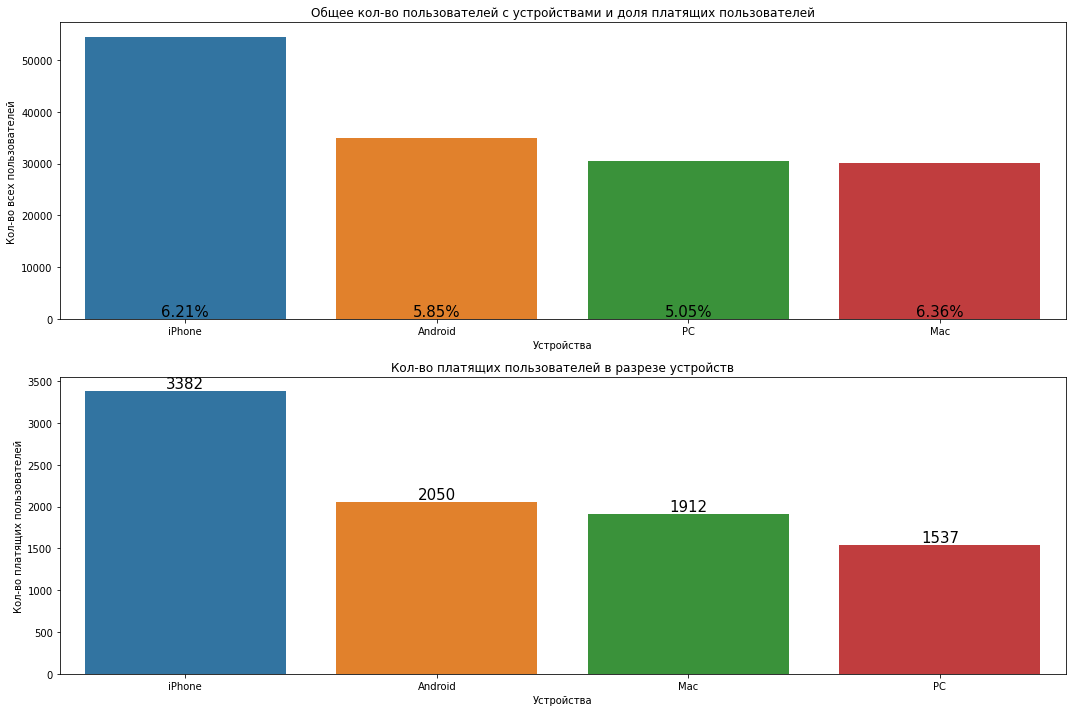

In [33]:
# Задаем размер сетки
plt.figure(figsize=(15, 10))
# Задаем 2 графика на 1 сетке, указываем 2 строки, 1 столбец, выбираем первое место
plt.subplot(2, 1, 1)
# Строим график распределения общего кол-ва пользователей и долю платящих
sns.barplot(x='device', y='user_id', data= device_payer)
plt.title('Общее кол-во пользователей с устройствами и доля платящих пользователей')
plt.xlabel('Устройства')
plt.ylabel('Кол-во всех пользователей')
# Выносим на график долю платящих пользователей
for index, value in enumerate(device_payer['payer_part']):
    plt.text(index, value+1, str(value)+'%', ha='center',va='bottom', fontsize = 15)

# Сортируем таблицу по кол-ву платящих пользователей    
device_payer = device_payer.sort_values(by='payer',ascending=False)

# Задаем на сетке месторасположение 2 графика
plt.subplot(2, 1, 2) 
# Строим график распределения кол-ва платящих пользователей с устройствами
sns.barplot(x='device', y='payer', data= device_payer)

plt.title('Кол-во платящих пользователей в разрезе устройств')
plt.xlabel('Устройства')
plt.ylabel('Кол-во платящих пользователей')
# Выносим на график значения
for index, value in enumerate(device_payer['payer']):
    plt.text(index, value+1, str(value), ha='center', va='bottom', fontsize = 15)
# Выравнивание графиков на сетке      
plt.tight_layout()
plt.show()

**Графики показывают, что больше всего посещают приложение обладаетли айфонов, на втором месте обладатели андроидов, далее обладатели PC и Mac.** 

**В абсолютных цифрах по кол-ву платящих распредляется так: первое место обладатели айфонов, далее андроиды, Mac и PC.**

**Но стоить отметить, что охотнее всех платят обладатели Mac и айфонов, если рассматривать долю платящих по устройствам. Не смотря на то, что с Mac заходит меньше всего пользователей, это ценные пользователи, потому что они совершают покупки. Обладателей Mac в принципе меньше среди всех устройств, что обуславливает последее место среди кол-ва посетителей приложения.**


#### Рекламные источники привлечения, из которых пришло больше всего платящих пользователей.

In [34]:
# Формируем таблицу с общим кол-вом пользователей, а также кол-вом и долей платящих пользователей
channel_payer = profiles.groupby(by='channel').agg({'user_id':'count','payer':'sum'}).reset_index()
channel_payer['payer_part'] = round((channel_payer['payer']/channel_payer['user_id'])*100,2)
channel_payer = channel_payer.sort_values(by='user_id', ascending=False) 
channel_payer

,channel,user_id,payer,payer_part
10,organic,56439,1160,2.06
1,FaceBoom,29144,3557,12.20
6,TipTop,19561,1878,9.60
4,OppleCreativeMedia,8605,233,2.71
2,LeapBob,8553,262,3.06
7,WahooNetBanner,8553,453,5.30
5,RocketSuperAds,4448,352,7.91
3,MediaTornado,4364,156,3.57
8,YRabbit,4312,165,3.83
0,AdNonSense,3880,440,11.34


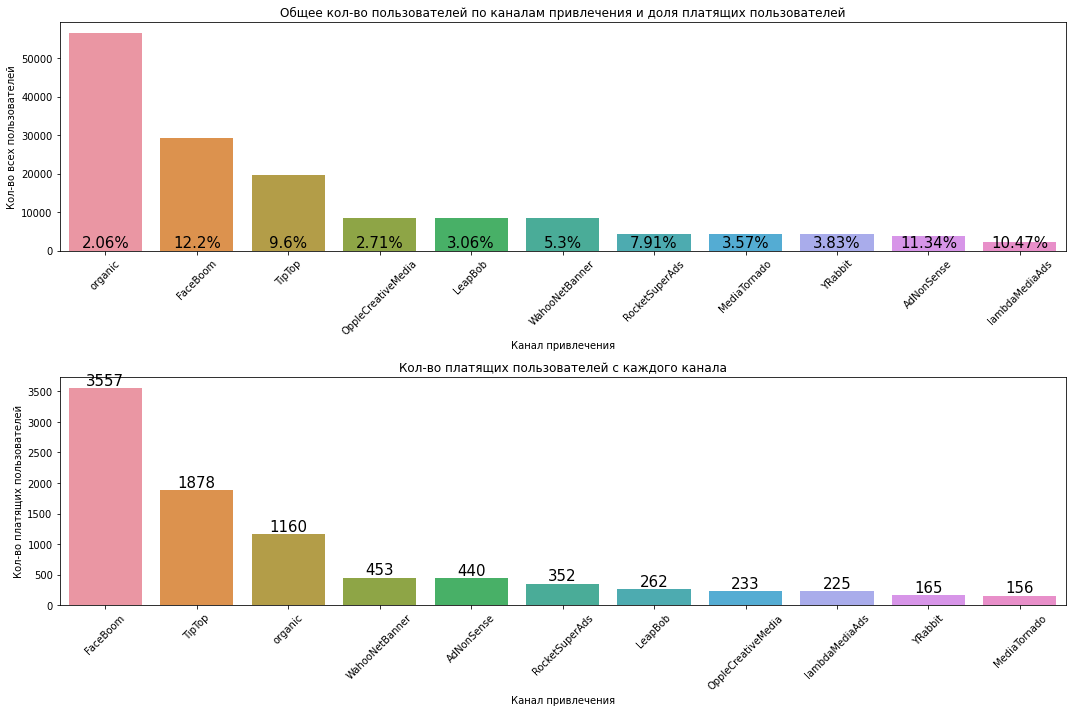

In [35]:
# Задаем размер сетки
plt.figure(figsize=(15, 10))
# Задаем 2 графика на 1 сетке, указываем 2 строки, 1 столбец, выбираем первое место
plt.subplot(2, 1, 1) 
# Строим график распределения общего кол-ва пользователей и долю платящих
sns.barplot(x='channel', y='user_id', data= channel_payer)
plt.title('Общее кол-во пользователей по каналам привлечения и доля платящих пользователей')
plt.xlabel('Канал привлечения')
plt.ylabel('Кол-во всех пользователей')
# Выносим на график долю платящих пользователей
for index, value in enumerate(channel_payer['payer_part']):
    plt.text(index, value+1, str(value)+'%', ha='center',va='bottom', fontsize = 15)
plt.xticks(rotation=45)

# Сортируем таблицу по кол-ву платящих пользователей   
channel_payer = channel_payer.sort_values(by='payer',ascending=False)

# Строим график распределения кол-ва платящих пользователей по каналам привлечения
plt.subplot(2, 1, 2)
sns.barplot(x='channel', y='payer', data= channel_payer)
plt.title('Кол-во платящих пользователей с каждого канала')
plt.xlabel('Канал привлечения')
plt.ylabel('Кол-во платящих пользователей')
# Выносим на график значения
for index, value in enumerate(channel_payer['payer']):
    plt.text(index, value+1, str(value), ha='center', va='bottom', fontsize = 15)
plt.xticks(rotation=45)
# Выравнивание графиков на сетке   
plt.tight_layout()
plt.show()

**В тройку лидеров, с отрывом в несколько раз, по кол-ву посетителей и покупателей в абсолютных цифрах входят каналы :FaceBoom, TipTop и органический траффик. Ценными могут быть ещё каналы AdNonSense и lambdaMediaAds, таких пользователей мало, но совершают покупки так же охотно , как с FaceBoom и TipTop.**

**С органического траффика приходит много посетителей и покупателей, но по качеству это самый низкий канал,  так как доля покупателей с органики самая низкая.**

## Маркетинг

#### Общая сумма расходов на маркетинг

In [36]:
marketing = costs['costs'].sum()
print('Общая сумма расходов на маркетинг:', round(marketing,2))

Общая сумма расходов на маркетинг: 105497.3


#### Распределение затрат по источникам.

In [37]:
# Строим таблицу с общими затратами по каналам
channel_costs = costs.groupby(by='channel').agg({'costs':'sum'}).reset_index().sort_values(by='costs', ascending=False)
channel_costs

,channel,costs
6,TipTop,54751.30
1,FaceBoom,32445.60
7,WahooNetBanner,5151.00
0,AdNonSense,3911.25
4,OppleCreativeMedia,2151.25
5,RocketSuperAds,1833.00
2,LeapBob,1797.60
9,lambdaMediaAds,1557.60
3,MediaTornado,954.48
8,YRabbit,944.22


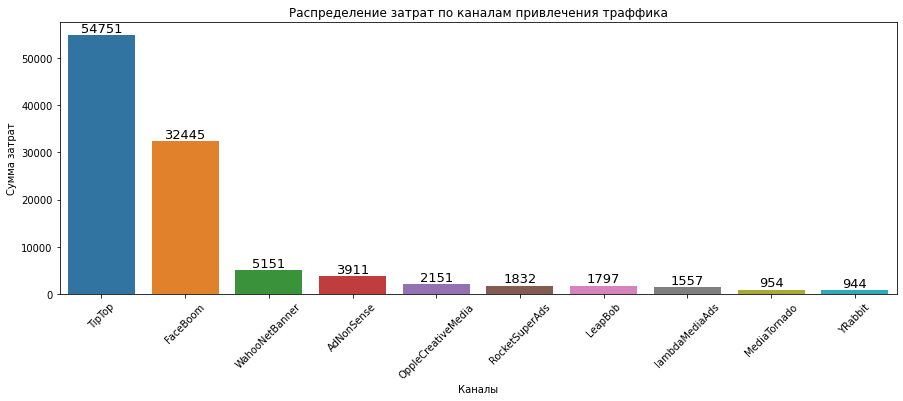

In [38]:
# Строим взуализацию для наглядности
plt.figure(figsize=(15, 5))
sns.barplot(x = 'channel',y='costs', data= channel_costs)
plt.title('Распределение затрат по каналам привлечения траффика')
plt.xlabel('Каналы')
plt.ylabel('Сумма затрат')
for index, value in enumerate(channel_costs['costs'].astype(int)):
    plt.text(index, value+1, str(value), ha='center', va='bottom', fontsize = 13)
plt.xticks(rotation=45)
plt.show()

**Основные вложения на привлечение траффика пришлись на FaceBoom и TipTop.**

**Остальные каналы либо тестировали, либо сами по себе каналы имеют небольшие охваты.**

#### Динамика затрат по неделям и месяцам. 

In [39]:
# Добавим новые столбцы с месяцем и неделей
costs['dt'] = pd.to_datetime(costs['dt'])
costs['month'] = costs['dt'].dt.strftime('%Y-%m')
costs['week'] = costs['dt'].astype('datetime64[W]')
costs.head(10)

,dt,channel,costs,month,week
0,2019-05-01,FaceBoom,113.3,2019-05,2019-04-25
1,2019-05-02,FaceBoom,78.1,2019-05,2019-05-02
2,2019-05-03,FaceBoom,85.8,2019-05,2019-05-02
3,2019-05-04,FaceBoom,136.4,2019-05,2019-05-02
4,2019-05-05,FaceBoom,122.1,2019-05,2019-05-02
5,2019-05-06,FaceBoom,118.8,2019-05,2019-05-02
6,2019-05-07,FaceBoom,101.2,2019-05,2019-05-02
7,2019-05-08,FaceBoom,100.1,2019-05,2019-05-02
8,2019-05-09,FaceBoom,93.5,2019-05,2019-05-09
9,2019-05-10,FaceBoom,104.5,2019-05,2019-05-09


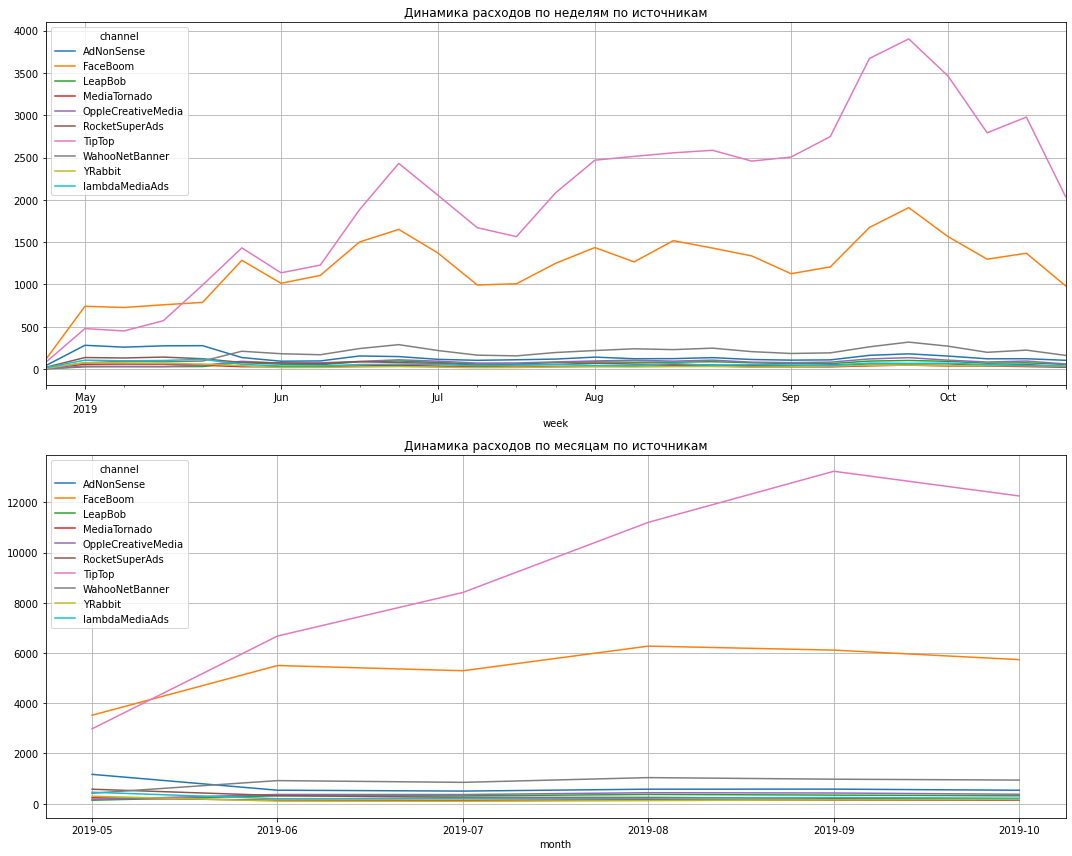

In [40]:
# Задаем размер сетки
fig, axs = plt.subplots(2, 1, figsize=(15, 12))
# Строим первый график 
costs.pivot_table(
    index='week',  
    columns='channel',  
    values='costs',  
    aggfunc='sum'  
).plot(ax=axs[0], grid=True)
axs[0].set_title('Динамика расходов по неделям по источникам')

# Строим второй график 
costs.pivot_table(
    index='month',  
    columns='channel',  
    values='costs',  
    aggfunc='sum'  
).plot(ax=axs[1], grid=True)
axs[1].set_title('Динамика расходов по месяцам по источникам')

# Выравниваем графики
plt.tight_layout()
plt.show()

**По графикам видно, как со временем увеличиваются расходы на каналы FaceBoom и TipTop, с пиками в конце июня и в конце сентября, скорее всего это обусловлено с сезонностью или какими -то важными событиями в сфере развлечений.**

**Канал TipTop лидер по вложениям,  к октябрю затраты выросли на 200% от стартовых вложений. В совокупности затраты на TipTop выше в 1,5 раза по сравнению с вложениями в FaceBoom, при этом кол-во покупателей меньше в 2 раза.**

**В канал FaceBoom было плавное повышение вложений, к октябрю вложения увеличились на 50%  от стартовых вложений. При этом из прошлых графиков мы помним, что FaceBoom лидер по кол-ву покупателей.**

**Необходимо проверить окупаемость затрат с канала TipTop, увеличенный уровень затрат вызывает подозрение, либо выбран в лидеры неверный канал, либо покупатели с данного канала совершают покупки на суммы в несколько раз выше , чем с FaceBoom. ** 

**У остальных источников затраты на одном уровне, без значительых калебаний.**

#### Расчет САС по каждому источнику.

In [41]:
# Строим таблицу CAC по источникам 

cac_channel = round(profiles
                    .groupby('channel')
                    .agg({'acquisition_cost': 'mean',
                          'user_id': 'nunique'})
                    .reset_index().sort_values(by='acquisition_cost', ascending=False),3)
cac_channel = cac_channel.rename(columns={'user_id':'user_count'})
cac_channel 

,channel,acquisition_cost,user_count
6,TipTop,2.799,19561
1,FaceBoom,1.113,29144
0,AdNonSense,1.008,3880
9,lambdaMediaAds,0.725,2149
7,WahooNetBanner,0.602,8553
5,RocketSuperAds,0.412,4448
4,OppleCreativeMedia,0.250,8605
8,YRabbit,0.219,4312
3,MediaTornado,0.219,4364
2,LeapBob,0.210,8553


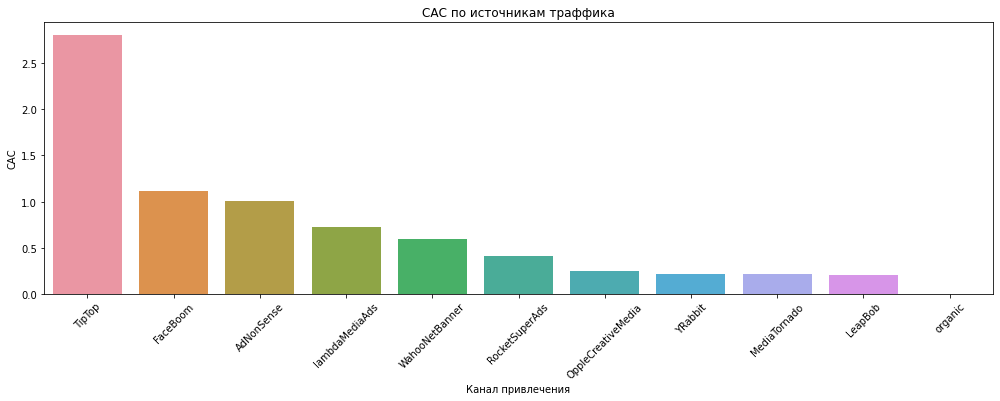

In [42]:
# Строим график САС по каждому источнику траффика
plt.figure(figsize=(17, 5))
sns.barplot(x = 'channel',y='acquisition_cost', data= cac_channel)
plt.title('САС по источникам траффика')
plt.xlabel('Канал привлечения')
plt.ylabel('САС')
plt.xticks(rotation=45)
plt.show()

**В продолжение анализа расходов, мы видим, что стоимость привлечения одного пользователя с канала TipTop в несколько раз выше , чем у FaceBoom и других каналов.**

## Оценка окупаемость рекламы

####  Оценка окупаемости с помощью LTV, CAC, ROI.

In [43]:
# задаем момент анализа
observation_date = datetime(2019, 11, 1).date()
# задаем горизонт анализа 
horizon_days = 14   

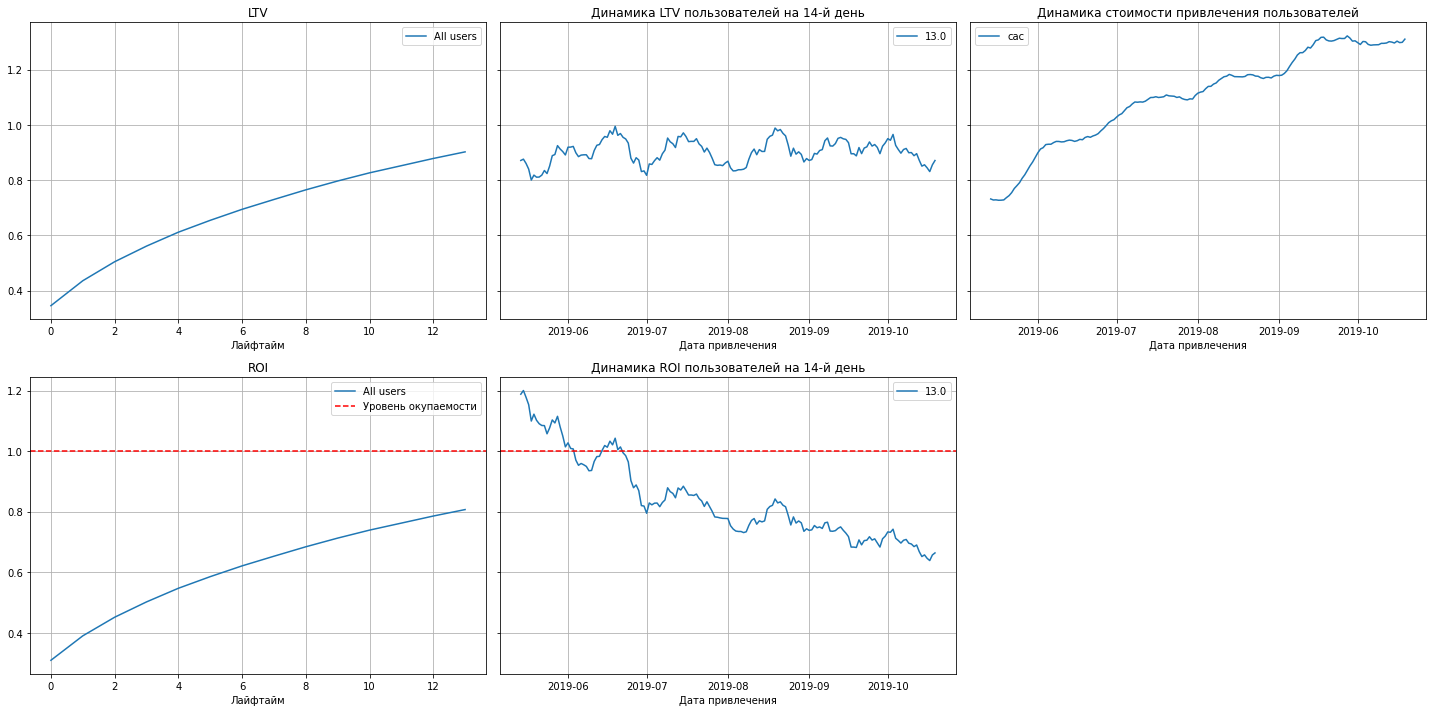

In [44]:
# считаем LTV и ROI без органического траффика
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Из общей ситуации можно сделать следующие выводы:**

**1. LTV на 14 день волнообразный , но достаточно стабильный и колеблется на одном уровне , с незначительными отклонениями. Значит, дело не в качестве пользователей.** 

**2. Реклама не достигает окупаемости. Динамика ROI 14 дня отрицательная. Отрицательный уровень окупаемости наблюдается уже на второй месяц запуска рекламной кампании.**

**3. Вместе с падением ROI наблюдается параллельно увеличение стоимости привлечения пользователей, как раз с июня увеличение затрат, и далее затраты только растут. Возможно, компания терпит убытки из-за неверного распределения маркетингового бюджета.**

**Чтобы подтвердить или опровергнуть данную гипотезу, нужно ещё рассмотреть динамику конверсии и удержания клиентов.**

#### Конверсия и удержание пользователей.

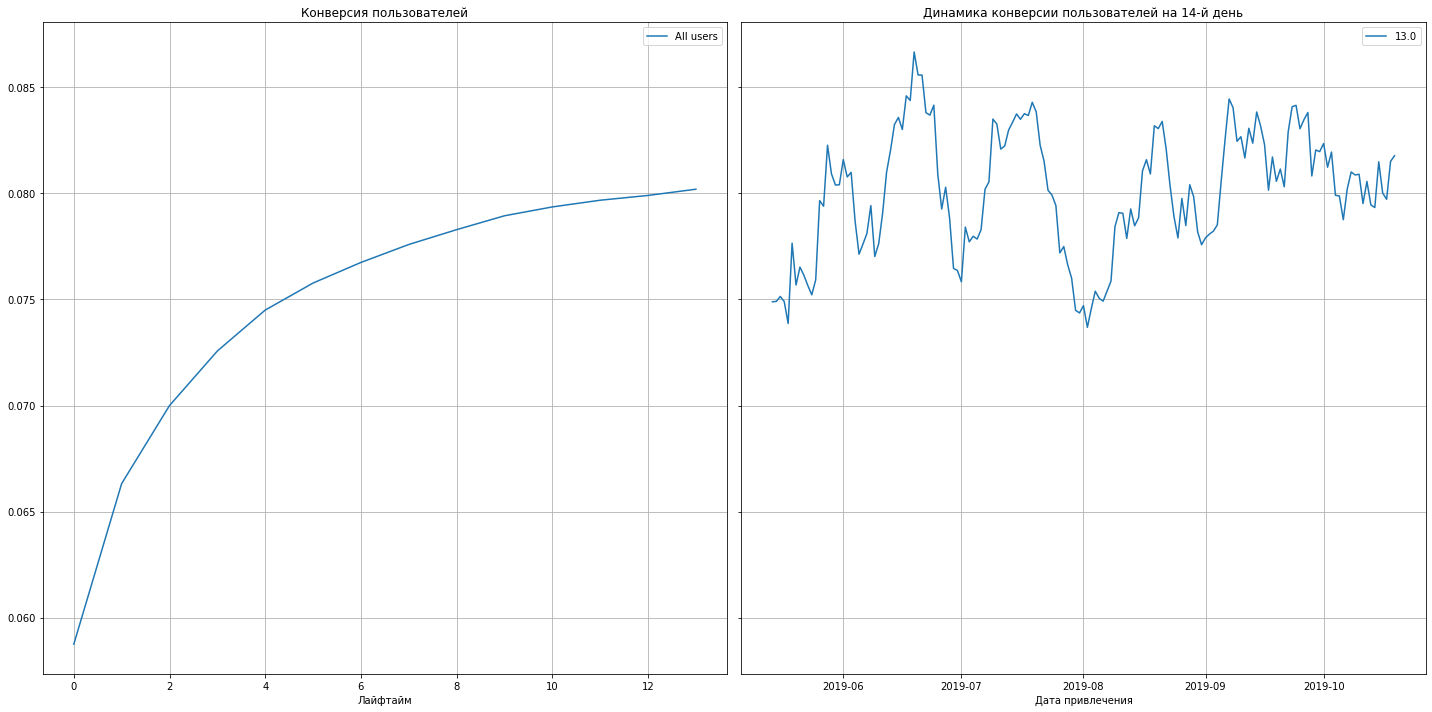

In [45]:
# смотрим общую конверсию, без органического траффика

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

**Судя по графикам, в общем пользователи с рекламных каналов хорошо конвертируются, уже на 4 день лайфтайм уровень конверсии достигает 7,5%, средний уровень конверсии на 14 день 8%.**

**Группа привлеченных 1 августа выделяется самым низким уровнем конверсии.**

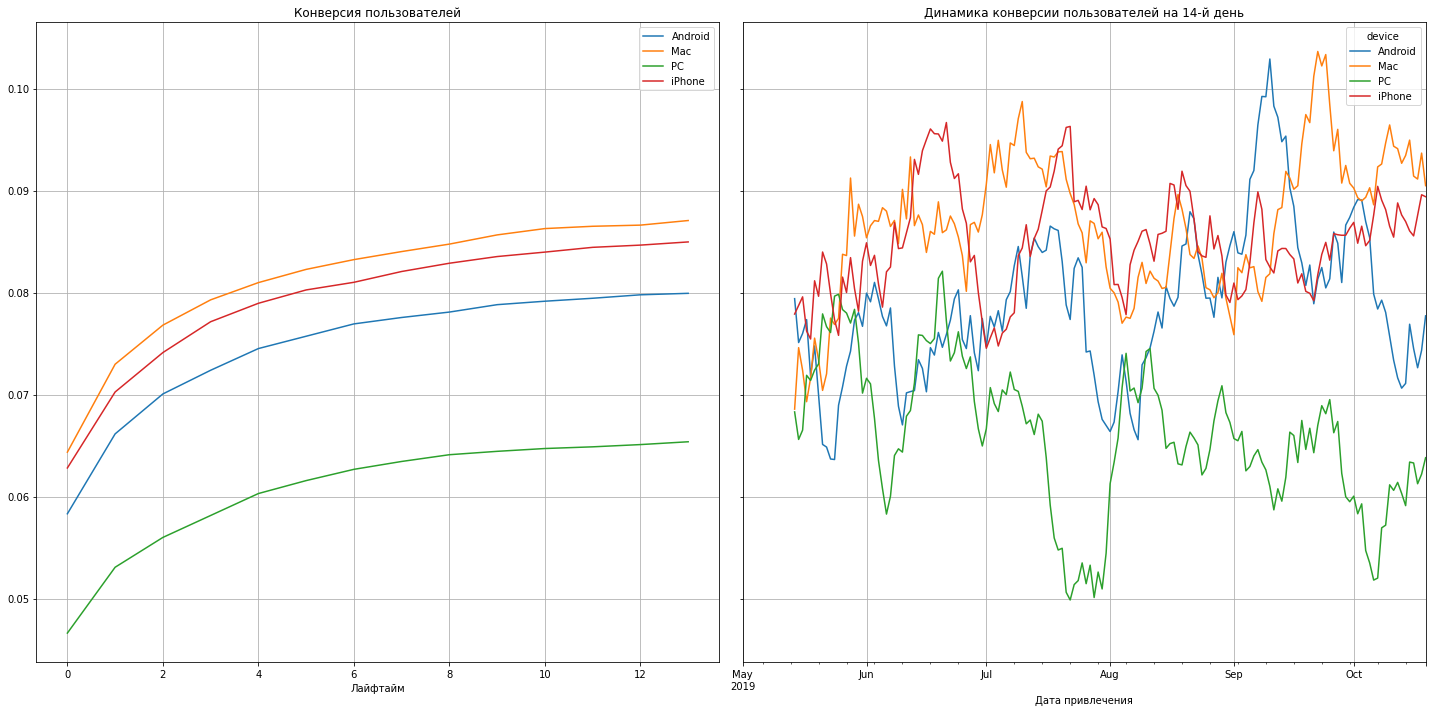

In [46]:
# смотрим  конверсию по устройствам, без органического траффика

dimensions = ['device']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions=dimensions )

plot_conversion(conversion_grouped, conversion_history, horizon_days)

**Лучше всех конвертируются пользователи с устройств Mac и Iphone.**

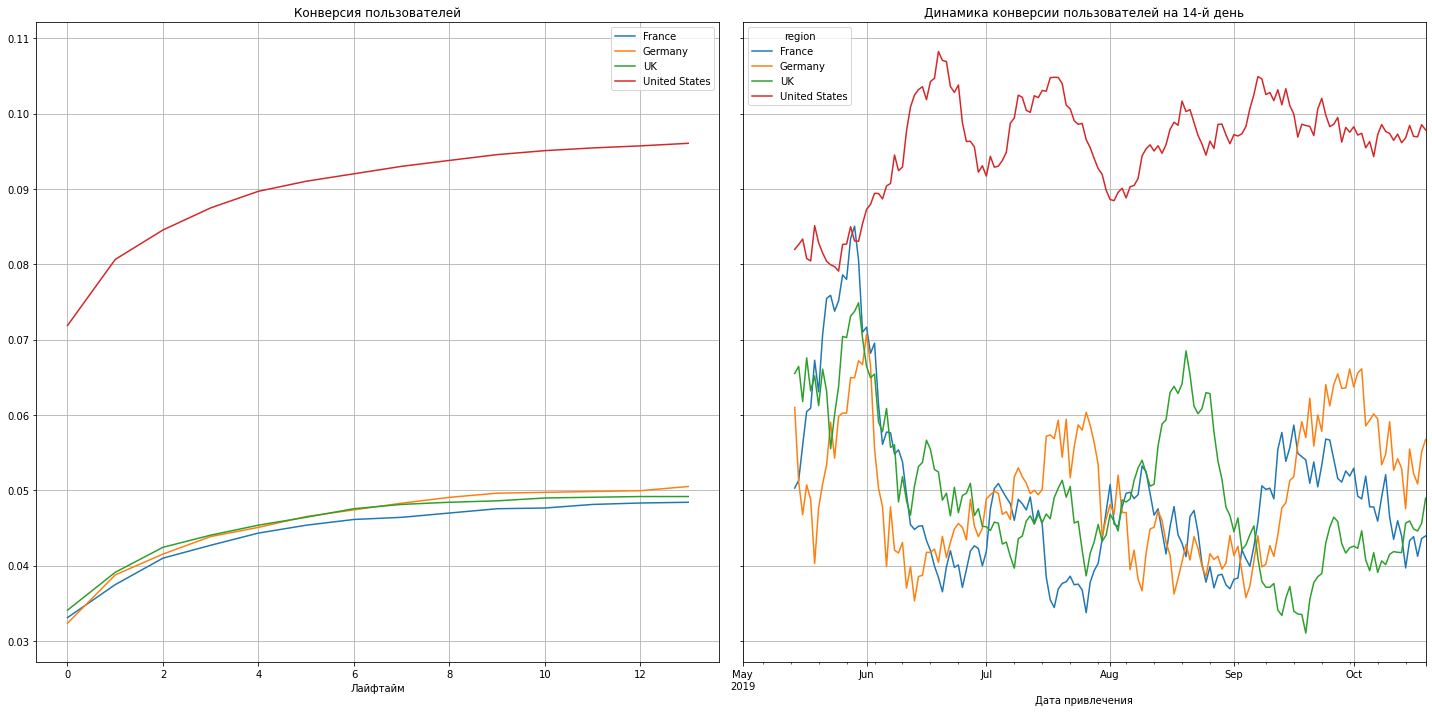

In [47]:
# смотрим  конверсию по странам, без органического траффика

dimensions = ['region']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions=dimensions )

plot_conversion(conversion_grouped, conversion_history, horizon_days)

**Пользователи из США конвертируются в 2 раза лучше, чем из других стран.**

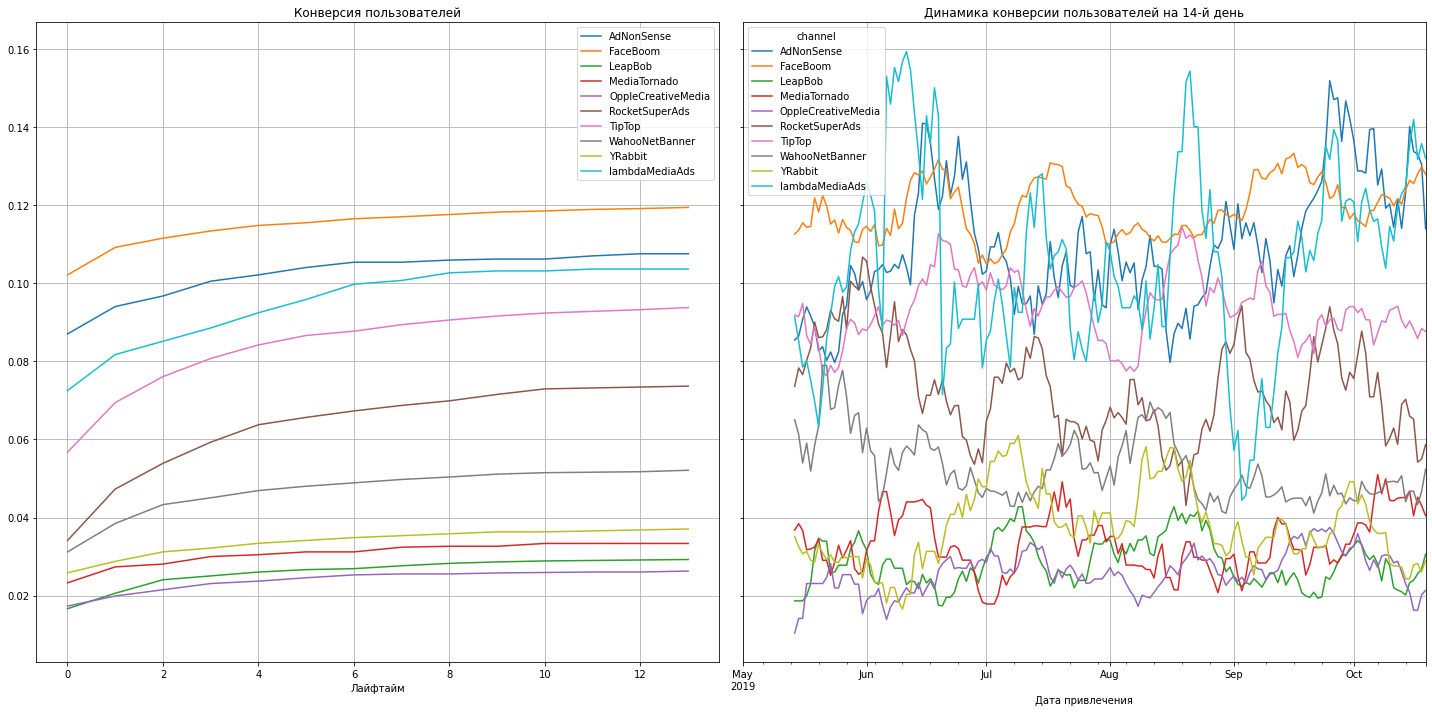

In [48]:
# смотрим  конверсию по источникам, без органического траффика

dimensions = ['channel']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions=dimensions )

plot_conversion(conversion_grouped, conversion_history, horizon_days)

**Канал FaceBoom на 1 месте по уровню конверсии, TipTop на 4 месте.** 

**На 2 и 3 месте AdNonSense и lambdaMediaAds.**

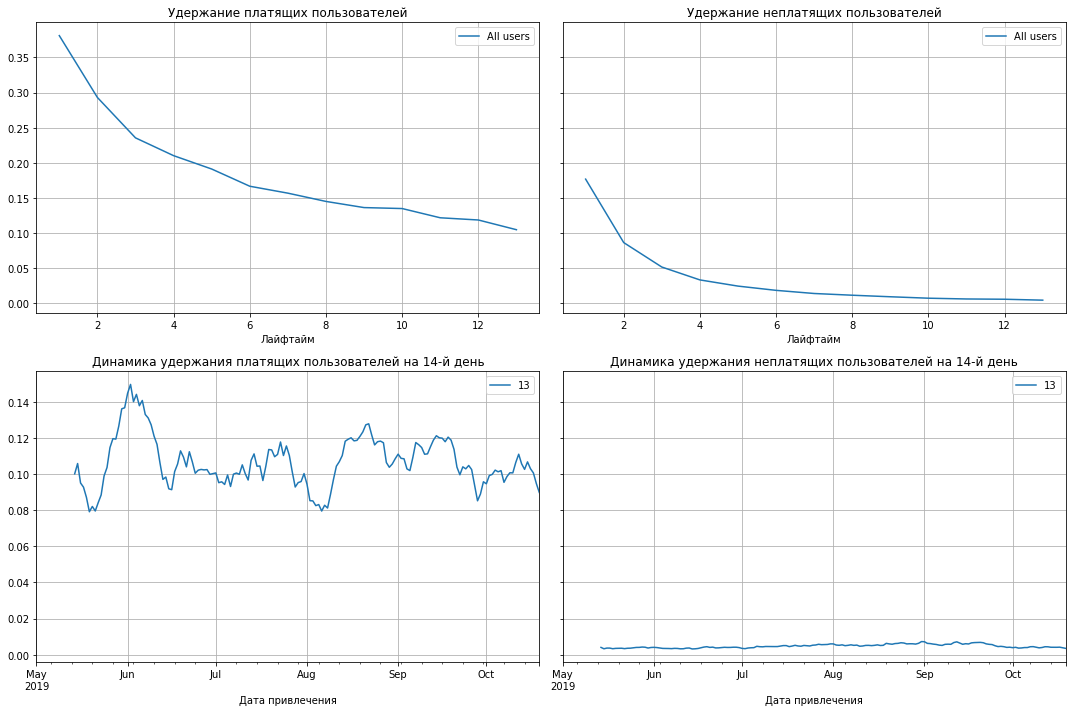

In [49]:
# смотрим удержание, без органического траффика

retention_raw, retention_grouped, retention_history = get_retention(
    profiles.query('channel!="organic"'), visits, observation_date, horizon_days)

plot_retention(retention_grouped, retention_history, horizon_days)

**Удержание платящих пользоватлей выше, чем неплатящих, здесь логично. Однако в динамике удержание платящих на 14-й день не стабильно, с всплесками и падениями. Общий уровень удержания низкий  . Рассмотрим более подробно удержание по разным признакам.**

**Здесь также выделяются привлеченные группы в начале августа с самым низким уровнем удержания.**

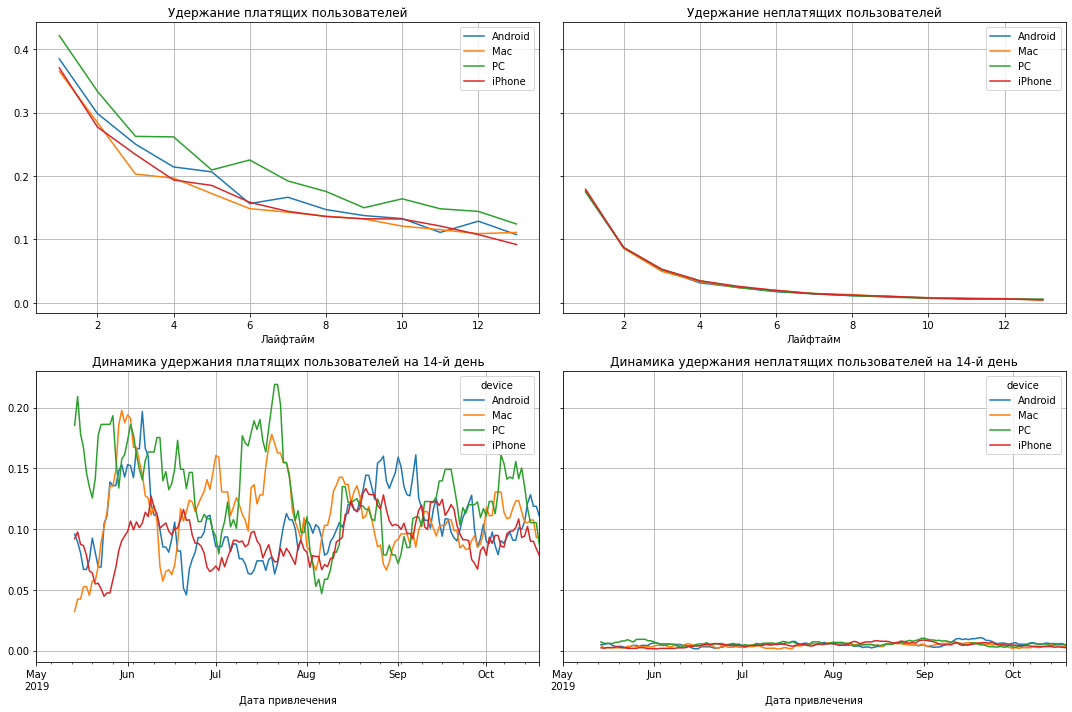

In [50]:
# смотрим удержание с разбивкой по устройствам, без органического траффика
dimensions = ['device']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles.query('channel!="organic"'), visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**Явных аномалий удержания по устройствам не замечено.**
**С устройств PC самое высокое удержание.**

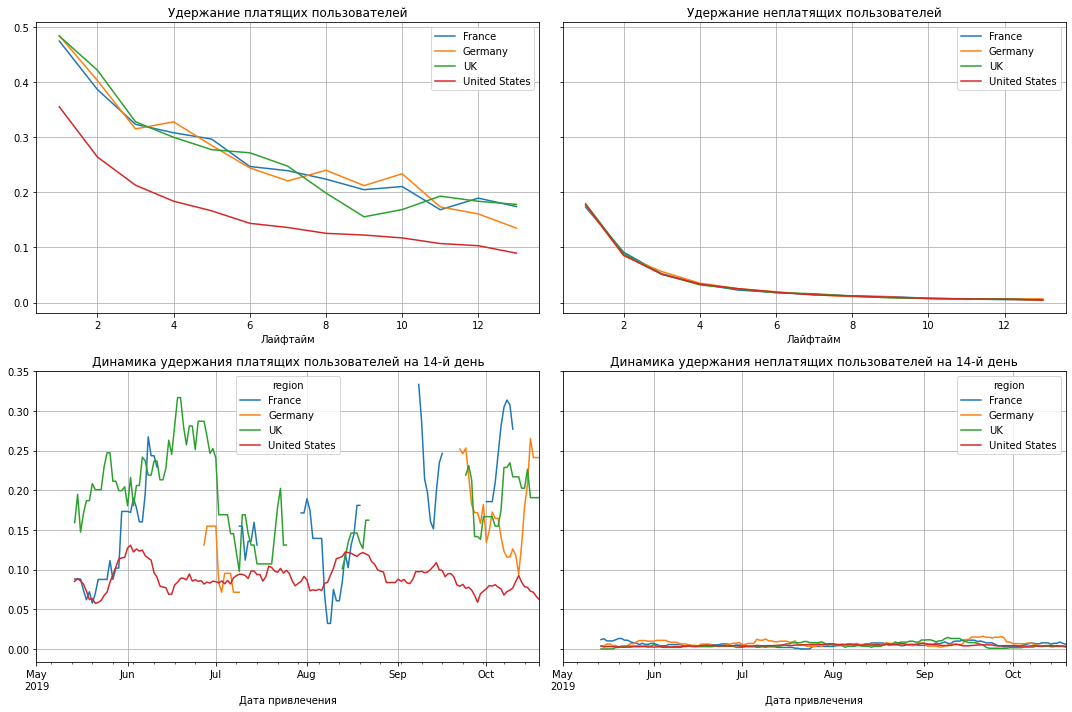

In [51]:
# смотрим удержание с разбивкой по странам, без органического траффика
dimensions = ['region']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles.query('channel!="organic"'), visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**Удержание пользователей из США стабильно ниже остальных стран. Но нужно заметить, что уровень удержания из США стабилен и сильно не колеблется. А пользователи из других стран, привлеченные с июля по октябрь на 14 день  лайфтайм удерживаются только эпизодически.** 

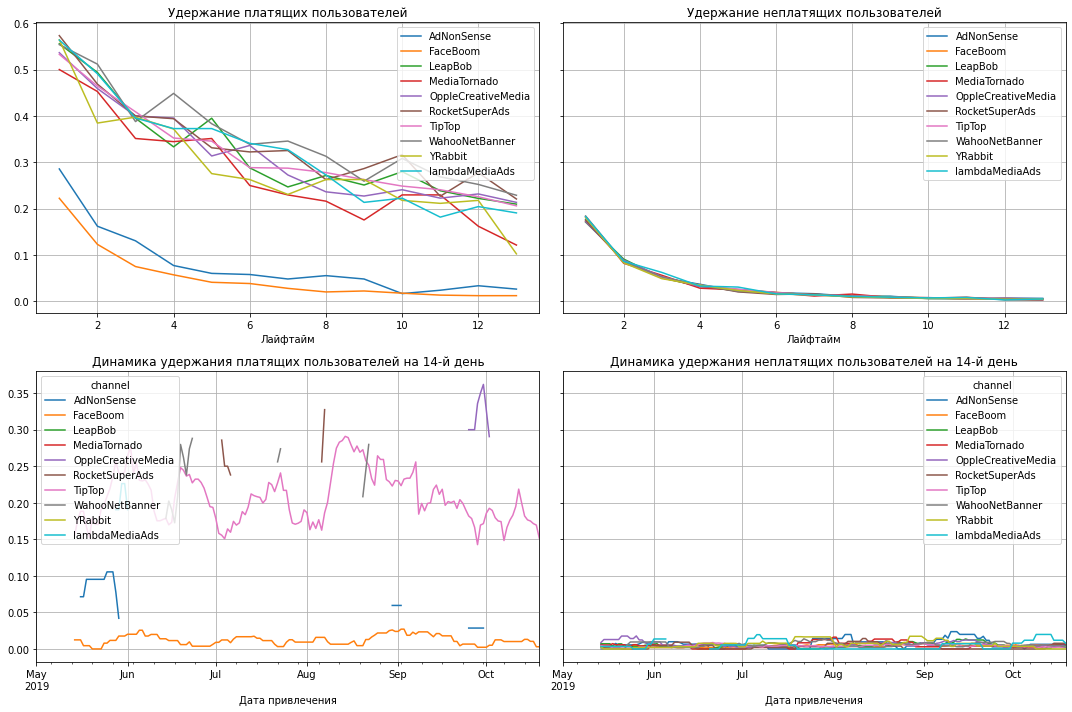

In [52]:
# смотрим удержание с разбивкой по рекламным каналам, без органического траффика
dimensions = ['channel']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles.query('channel!="organic"'), visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**У FaceBoom и AdNonSense заметно низкий уровень удержания по сравнению с остальными каналами. Однако самые стабильные каналы по удержанию TipTop и FaceBoom, пользователи с данных каналов всегда возращаются  на 14 день.**

#### Анализ окупаемости рекламы с разбивкой по устройствам.

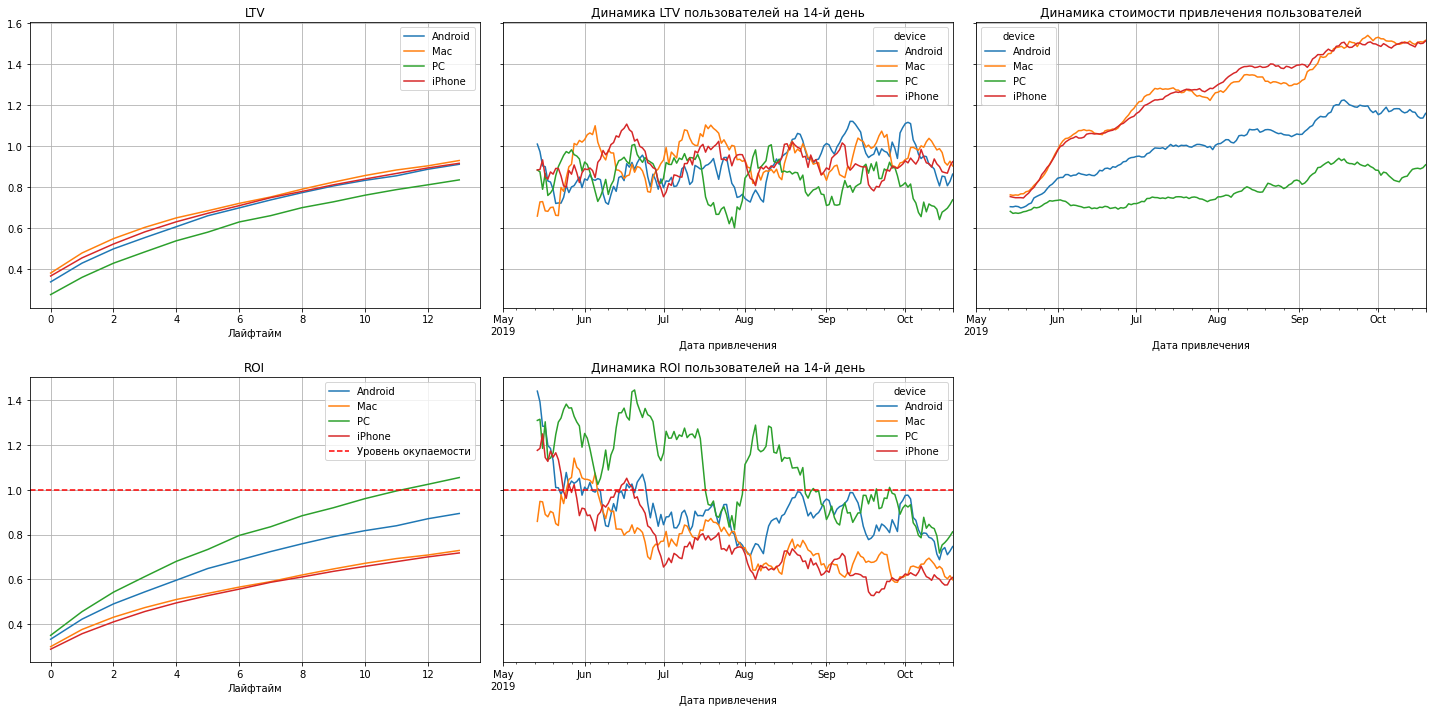

In [53]:
# считаем LTV и ROI с разбивкой по устройствам
dimensions = ['device']
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions = dimensions)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Затраты по каждому устройству растут пропорционально общему росту расходов, больше всего рост затрат приходится на обладателей устройств Apple и Mac. Именно у Mac и Айфонов самый низкий ROI и падает сильнее остальных устройств , реклама по этим устройствам не окупается с июня.**

**Затраты окупаются только по устройствам PC до сентября. С сентября происходит очередное увеличение затрат на рекламу, ROI по устройствам PC падает ниже уровня окупаемости.**

#### Анализ окупаемости с разбивкой по странам.

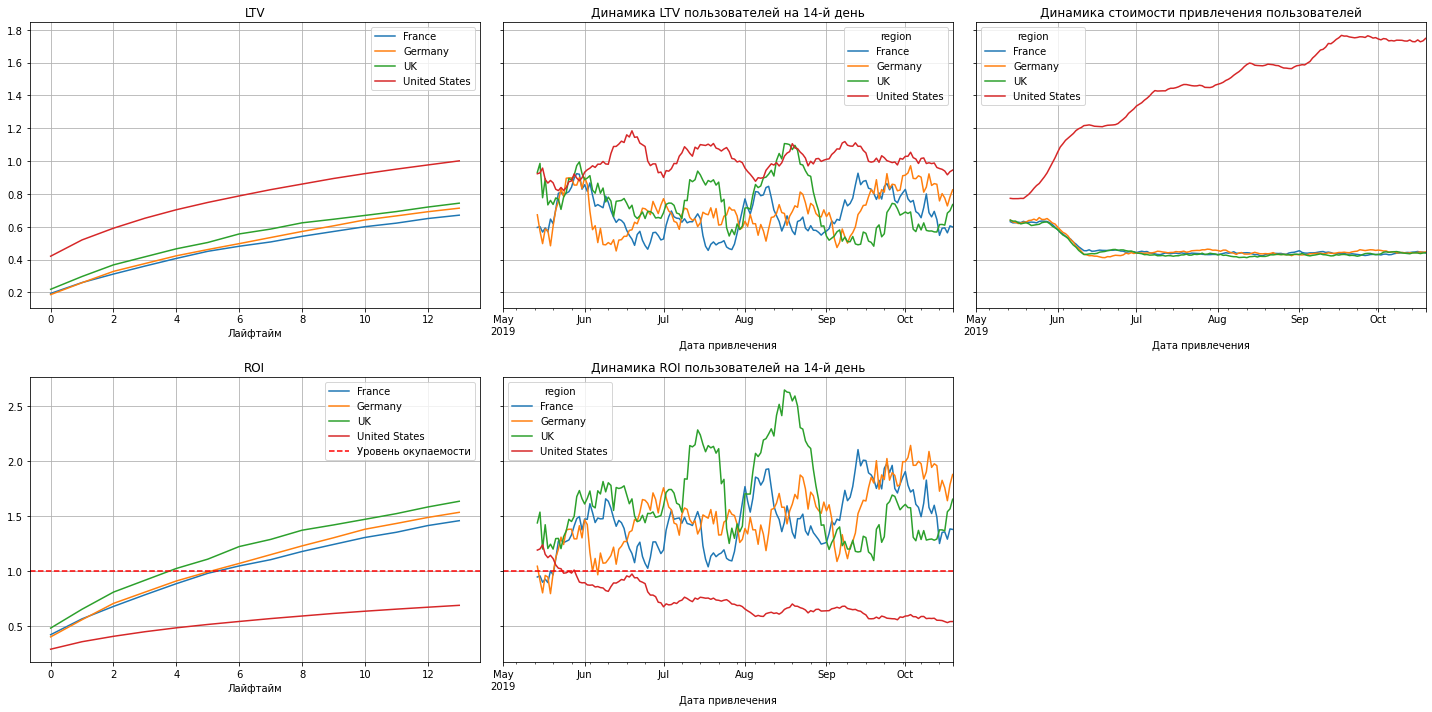

In [54]:
# считаем LTV и ROI с разбивкой по странам
dimensions = ['region']
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions = dimensions)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Видимо расходы на привлечение обладателей Apple приходятся больше всего на жителей США. Затраты не окупаются именно на привлечение пользователей из США, не смотря на самый высокий LTV из этой страны. По всем станам , кроме США затраты c июня колеблются на одном уровне и ROI стабильно растет, окупаясь уже на 4-6 дни.**

**Проверим, сколько приходится устройств на США.**

In [55]:
profiles.pivot_table(index = 'device', columns = 'region', values = 'payer', aggfunc='sum')

region,France,Germany,UK,United States
device,,,,
Android,179,182,202,1487
Mac,82,61,63,1706
PC,268,253,301,715
iPhone,134,120,134,2994


**Действительно, в США основная доля пользователей айфонов и Mac. В осатльных странах преобладают Android	 и PC.**

#### Анализ окупаемости с разбивкой по рекламным каналам.

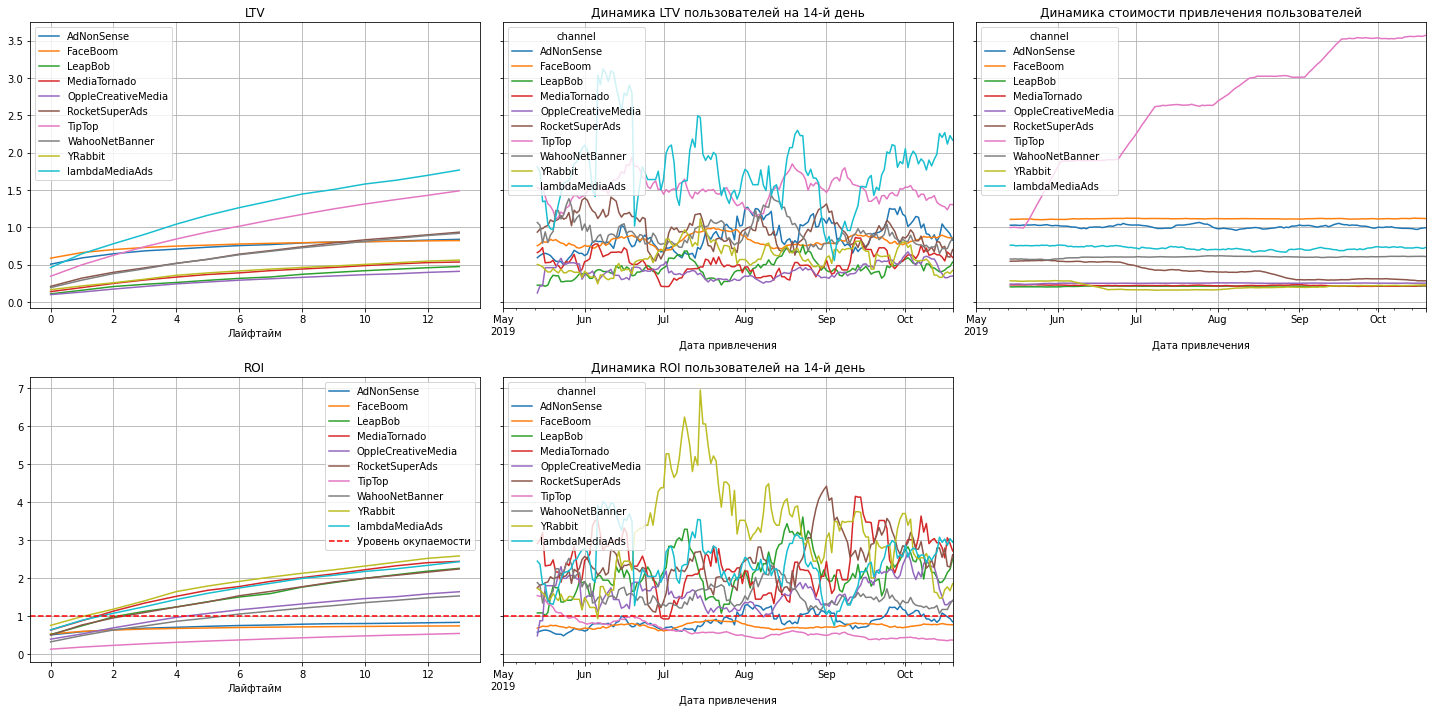

In [56]:
# считаем LTV и ROI с разбивкой по рекламным каналам
dimensions = ['channel']
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel!="organic"'), orders, observation_date, horizon_days, dimensions = dimensions)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Ключевые каналы привлечения FaceBoom и TipTop не окупаются и с самым низким показателем ROI, именно по данным каналам больше всего затрат. При этом у покупателей с TipTop LTV один из самых высоких. Стоит обратить внимание на lambdaMediaAds - у пользователей этого канала самый высокий LTV, возможно это канал, который необходимо развивать.** 

**Также проверим, сколько приходится покупателей с FaceBoom и TipTop на США.**

In [57]:
profiles.pivot_table(index = 'channel', columns = 'region', values = 'payer', aggfunc='sum')

region,France,Germany,UK,United States
channel,,,,
AdNonSense,150.0,142.0,148.0,NaN
FaceBoom,NaN,NaN,NaN,3557.0
LeapBob,90.0,69.0,103.0,NaN
MediaTornado,NaN,NaN,NaN,156.0
OppleCreativeMedia,80.0,64.0,89.0,NaN
RocketSuperAds,NaN,NaN,NaN,352.0
TipTop,NaN,NaN,NaN,1878.0
WahooNetBanner,152.0,148.0,153.0,NaN
YRabbit,NaN,NaN,NaN,165.0


**Ключевые каналы привечения траффика направленны на потенциальных покупателей из США.**

**Конвертируются пользователи США лучше остальных стран.**

## Выводы и рекомендации:

Анализ показал, что реклама , направленная на привлечение пользователей не окупается. Общий ROI ниже черты окупаемости и стремится к падению.

**Можно выделить несколько причин убытков компании:**

- Высокие затраты на рекламу, направленную на пользователей из США в каналах FaceBoom и TipTop

- Высокие затраты на рекламу, направленную на обладателей Iphone и Mac

- Низкое удержание клиентов, привлеченных из США с канала FaceBoom

- Высокие затраты на рекламу в канале AdNonSense


Рекламная кампания направленна на пользователей из США, LTV по данной стране самый высокий, с США больше всего пользователей, пользователи лучше остальных стран конвертируются и стабильнее других стран удерживаются. В США процент конвертации в среднем достигает 9,5% на 14 день, в других странах 5%. Но процент удержания самый низкий, по сравнению с другими странами и в динамике на 14 день колеблется в среднем между 7-13%. А пользователи из других стран, привлеченные с июля по октябрь на 14 день лайфтайм удерживаются только эпизодически, но процент удержания на 14 день колеблется от 5% до 33%, в  среднем 15% - 18%.
 
Лучше всех конвертируются пользователи с устройств Mac и Iphone. Хуже всех конвертируются с устройств PC, но имеют самое высокое удержание. Основная масса обладателей Iphone и Mac являются пользователями  США.

Основные источники привлечения аудитории каналы FaceBoom и TipTop. Пользователями с данных каналов являются жителями США. В данные каналы больше всего было вложений.

Канал TipTop лидер по вложениям, у данного канала самый высокий LTV, хороший уровень удержания от 15% до 30% на 14 день, по уровню конверсии TipTop на 4 месте по сравнению с другими каналами.

Канал FaceBoom на втором месте по вложениям. Этот канал - лидер по уровню конверсии и кол-ву покупателей. Уровень удержания стабильный, но процент возврата низкий на уровне 2%-3%. 

Важно отметить  каналы AdNonSense и lambdaMediaAds: таких пользователей мало, но совершают покупки так же охотно , как с FaceBoom и TipTop. Каналы находятся на 2 и 3 месте  по уровню конвертации. Это пользователи из UK, Германии и Франции. У AdNonSense заметно низкий уровень удержания, можно порекомендовать отделу маркетинга доп. стимулирующие меропрития для удрежания аудитоории. 



**Рекомендации для отдела маркетинга:**

- Снизить расходы до уровня затрат июня, так как с июня ROI падает ниже уровня окупаемости:

а. снизить расходы на привлечение пользователей из США, за счёт снижения затрат на привлечение обладателей айфонов и Mac. 

б. снизить расходы на привлечение пользователей с FaceBoom и TipTop.

- для пользователей из США, в особенности привлеченных с канала FaceBoom разработать дополнительные стимулирующие акции, программы лояльности для увеличения удержания

- масштабировать привлечение пользователей из других стран с каналов lambdaMediaAds и AdNonSense 

- также для пользователей с UK , Германии и Франции и с каналов lambdaMediaAds и AdNonSense разработать дополнительные стимулирующие акции, программы лояльности для увеличения удержания
